version plus organiser historique only

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

from ipywidgets import interact, SelectMultiple

load data

In [3]:
df = pd.read_csv("data/FINAL_DATASET_PREDICTION_CEjour.csv")

# ⚠️ garder si tu veux (mais pas optimal)
df.dropna(inplace=True)

print(df.shape)

(485151, 33)


SPLIT PUITS (FIXE)

In [4]:
wellnames = df["WELL"].dropna().unique().tolist()

np.random.seed(42)
np.random.shuffle(wellnames)

train_wells = wellnames[:80]
blind_wells = wellnames[80:89]

print("Train wells:", len(train_wells))
print("Blind wells:", len(blind_wells))

#sauvegarde 
with open("split.json", "w") as f:
    json.dump({"train": train_wells, "blind": blind_wells}, f)

Train wells: 80
Blind wells: 9


FEATURES / TARGET

In [5]:
features = [
    "WHP","WHT",
    "WHP_LAG_3","WHP_LAG_7",
    "WHT_LAG_3","WHT_LAG_7",
    "GAS_LAG_3","GAS_LAG_7",
    "WATER_LAG_3","WATER_LAG_7",
    "COND_LAG_3","COND_LAG_7",

    "W_GAS_MEAN_3","W_GAS_MEAN_7",
    "WATER_MEAN_3","WATER_MEAN_7",
    "COND_VOL_MEAN_3","COND_VOL_MEAN_7",

    "DAY","MONTH","DAY_OF_WEEK"
]

targets = ["W_GAS","WATER","COND_VOL"]

DATASETS

In [6]:
# ==============================
# TRAIN / TEST SPLIT (NO LEAKAGE)
# ==============================

train_list = []
test_list = []

for well in train_wells:

    df_w = df[df["WELL"] == well].sort_values("DATE")

    split_index = int(len(df_w) * 0.8)

    train_list.append(df_w.iloc[:split_index])
    test_list.append(df_w.iloc[split_index:])

train_df = pd.concat(train_list)
test_df  = pd.concat(test_list)

# FINAL MATRICES
X_train = train_df[features]
y_train = train_df[targets]

X_test  = test_df[features]
y_test  = test_df[targets]

# BLIND stays untouched
df_blind = df[df["WELL"].isin(blind_wells)].copy()
X_blind = df_blind[features]
y_blind = df_blind[targets]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Blind shape:", X_blind.shape)

Train shape: (353758, 21)
Test shape : (88486, 21)
Blind shape: (42907, 21)


FONCTION GÉNÉRIQUE MODEL

In [7]:
def run_model(name, model):

    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)
    y_blind_pred = pipe.predict(X_blind)

    for i, target in enumerate(targets):
        print(f"{target}:")
        print(" Train R2:", r2_score(y_train.iloc[:, i], y_train_pred[:, i]))
        print(" Test  R2:", r2_score(y_test.iloc[:, i], y_test_pred[:, i]))
        print(" Blind R2:", r2_score(y_blind.iloc[:, i], y_blind_pred[:, i]))

    # 🔥 SAUVEGARDE
    

    return pipe, y_train_pred, y_test_pred, y_blind_pred

MODELS

In [8]:
# Linear
lr_model, y_train_lr, y_test_lr, y_blind_lr = run_model(
    "LinearRegression", LinearRegression()
)



===== LinearRegression =====
W_GAS:
 Train R2: 0.943210830537067
 Test  R2: 0.9423272626813025
 Blind R2: 0.9342171137865382
WATER:
 Train R2: 0.9692135314574033
 Test  R2: 0.9726157426571298
 Blind R2: 0.8960662317114365
COND_VOL:
 Train R2: 0.9552840987500428
 Test  R2: 0.9325715710818987
 Blind R2: 0.9548987778051536


In [9]:
# Random Forest
rf_model, y_train_rf, y_test_rf, y_blind_rf = run_model(
    "RandomForest",
    RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
)


===== RandomForest =====


W_GAS:
 Train R2: 0.8860625680813962
 Test  R2: 0.7320484691842563
 Blind R2: 0.8347126578412023
WATER:
 Train R2: 0.9284990823907722
 Test  R2: 0.9249363121795409
 Blind R2: 0.7527123468258352
COND_VOL:
 Train R2: 0.966222111838361
 Test  R2: 0.9480584796776713
 Blind R2: 0.9448648329077052


In [10]:
# Decision Tree
dt_model, y_train_dt, y_test_dt, y_blind_dt = run_model(
    "DecisionTree", DecisionTreeRegressor(max_depth=10)
)


===== DecisionTree =====
W_GAS:
 Train R2: 0.8824162413636188
 Test  R2: 0.7177987147850012
 Blind R2: 0.8279266854204632
WATER:
 Train R2: 0.9138159805992334
 Test  R2: 0.8735202210818289
 Blind R2: 0.7242929389945556
COND_VOL:
 Train R2: 0.9640264925896413
 Test  R2: 0.9381214038124039
 Blind R2: 0.9517705889537232


In [11]:
from xgboost import XGBRegressor

In [12]:
# XGBoost
xgb_model, y_train_xgb, y_test_xgb, y_blind_xgb = run_model(
    "XGBoost",
    XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)


===== XGBoost =====
W_GAS:
 Train R2: 0.9597969904178224
 Test  R2: 0.9593382796015132
 Blind R2: 0.9455352121268659
WATER:
 Train R2: 0.9840240245026128
 Test  R2: 0.9459699311300035
 Blind R2: 0.9017069405415397
COND_VOL:
 Train R2: 0.9696389749989203
 Test  R2: 0.9578866932096919
 Blind R2: 0.9605772337427576


ANN (STRUCTURÉ)

In [ ]:
def run_ann():
    os.makedirs("models", exist_ok=True)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_blind_s = scaler.transform(X_blind)

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(3)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train_s, y_train.values, epochs=50, batch_size=512, verbose=0)

    y_train_pred = model.predict(X_train_s)
    y_test_pred  = model.predict(X_test_s)
    y_blind_pred = model.predict(X_blind_s)
    
    return model, y_train_pred, y_test_pred, y_blind_pred


ann_model, y_train_ann, y_test_ann, y_blind_ann = run_ann()

a:\pfe master\PEG_Python-master\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11055/11055 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
2766/2766 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


COMPARAISON

In [14]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2  = r2_score(y_true.iloc[:, i], y_pred[:, i])

        print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")


evaluate_model("LR", y_test, y_test_lr)
evaluate_model("DT", y_test, y_test_dt)
evaluate_model("RF", y_test, y_test_rf)
evaluate_model("ANN", y_test, y_test_ann)
evaluate_model("XGB", y_test, y_test_xgb)


===== LR =====
W_GAS -> MAE: 0.0088 | R2: 0.9423
WATER -> MAE: 0.2112 | R2: 0.9726
COND_VOL -> MAE: 1.3721 | R2: 0.9326

===== DT =====
W_GAS -> MAE: 0.0401 | R2: 0.7178
WATER -> MAE: 1.0247 | R2: 0.8735
COND_VOL -> MAE: 1.5989 | R2: 0.9381

===== RF =====
W_GAS -> MAE: 0.0393 | R2: 0.7320
WATER -> MAE: 0.8416 | R2: 0.9249
COND_VOL -> MAE: 1.3336 | R2: 0.9481

===== ANN =====
W_GAS -> MAE: 0.0205 | R2: 0.9069
WATER -> MAE: 0.3063 | R2: 0.9736
COND_VOL -> MAE: 1.4846 | R2: 0.9517

===== XGB =====
W_GAS -> MAE: 0.0076 | R2: 0.9593
WATER -> MAE: 0.3716 | R2: 0.9460
COND_VOL -> MAE: 1.1334 | R2: 0.9579


SAVE RESULTS

In [ ]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    for i, target in enumerate(targets):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2  = r2_score(y_true.iloc[:, i], y_pred[:, i])

        print(f"{target} -> MAE: {mae:.4f} | R2: {r2:.4f}")


evaluate_model("LR", y_test, y_test_lr)
evaluate_model("DT", y_test, y_test_dt)
evaluate_model("RF", y_test, y_test_rf)
evaluate_model("ANN", y_test, y_test_ann)
evaluate_model("XGB", y_test, y_test_xgb)

In [ ]:
# ==============================
# SAVE XGBOOST RESULTS physics only to comarison with the other cases
# ==============================

xgb_results = []

for i, target in enumerate(targets):

    r2 = r2_score(
        y_blind.iloc[:, i],
        y_blind_xgb[:, i]
    )

    xgb_results.append({
        "Target": target,
        "R2": r2
    })

df_xgb_results = pd.DataFrame(xgb_results)

df_xgb_results.to_csv(
    "comparison/results/History_Only_xgb_results.csv",
    index=False
)

INTERACTIVE PLOT

In [15]:
df_plot = df_blind.loc[X_blind.index].copy()
df_plot["DATE"] = pd.to_datetime(df_plot["DATE"])

df_plot["LR"] = y_blind_lr[:,0]
df_plot["RF"] = y_blind_rf[:,0]
df_plot["ANN"] = y_blind_ann[:,0]
df_plot["DT"] = y_blind_dt[:,0]
df_plot["XGB"] = y_blind_xgb[:,0]

def plot_wells(model="LR"):

    wells = df_plot["WELL"].unique()

    fig, ax = plt.subplots(3,2, figsize=(20,20))

    row = [0,0,1,1,2,2]
    col = [0,1,0,1,0,1]

    for i, well in enumerate(wells[:6]):

        dfp = df_plot[df_plot["WELL"] == well]

        ax[row[i], col[i]].scatter(dfp["DATE"], dfp["W_GAS"], label="Real")
        ax[row[i], col[i]].plot(dfp["DATE"], dfp[model], color="green", label=model)

        ax[row[i], col[i]].set_title(well)
        ax[row[i], col[i]].legend()

    plt.tight_layout()
    plt.show()


interact(plot_wells, model=["LR","RF","ANN","DT","XGB"])

interactive(children=(Dropdown(description='model', options=('LR', 'RF', 'ANN', 'DT', 'XGB'), value='LR'), Out…

<function __main__.plot_wells(model='LR')>

comparison table

In [16]:
def build_blind_comparison():

    results = []

    models = {
        "LR": y_blind_lr,
        "DT": y_blind_dt,
        "RF": y_blind_rf,
        "XGB":y_blind_xgb,
        "ANN": y_blind_ann
    }

    for model_name, y_pred in models.items():

        for i, target in enumerate(targets):

            mae = mean_absolute_error(y_blind.iloc[:, i], y_pred[:, i])
            r2  = r2_score(y_blind.iloc[:, i], y_pred[:, i])

            results.append({
                "Model": model_name,
                "Target": target,
                "MAE": mae,
                "R2": r2
            })

    return pd.DataFrame(results)

In [17]:
df_blind_compare = build_blind_comparison()
print(df_blind_compare)

   Model    Target       MAE        R2
0     LR     W_GAS  0.013308  0.934217
1     LR     WATER  0.334104  0.896066
2     LR  COND_VOL  2.256474  0.954899
3     DT     W_GAS  0.039604  0.827927
4     DT     WATER  1.184327  0.724293
5     DT  COND_VOL  2.577831  0.951771
6     RF     W_GAS  0.038773  0.834713
7     RF     WATER  1.076183  0.752712
8     RF  COND_VOL  2.466329  0.944865
9    XGB     W_GAS  0.012268  0.945535
10   XGB     WATER  0.342276  0.901707
11   XGB  COND_VOL  2.152157  0.960577
12   ANN     W_GAS  0.025189  0.916068
13   ANN     WATER  0.397469  0.906837
14   ANN  COND_VOL  2.303505  0.963014


In [18]:
pivot_r2 = df_blind_compare.pivot(index="Model", columns="Target", values="R2")
print(pivot_r2)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.963014  0.906837  0.916068
DT      0.951771  0.724293  0.827927
LR      0.954899  0.896066  0.934217
RF      0.944865  0.752712  0.834713
XGB     0.960577  0.901707  0.945535


selection of the best model

In [19]:
df_global = df_blind_compare.groupby("Model")["R2"].mean().reset_index()
df_global = df_global.sort_values("R2", ascending=False)

print(df_global)

best_model = df_global.iloc[0]["Model"]
print("Best model:", best_model)

  Model        R2
4   XGB  0.935940
0   ANN  0.928640
2    LR  0.928394
3    RF  0.844097
1    DT  0.834663
Best model: XGB


pearson correlation


In [20]:
def pearson_model(name, y_true, y_pred):

    results = []

    for i, target in enumerate(targets):

        corr = np.corrcoef(y_true.iloc[:, i], y_pred[:, i])[0,1]

        results.append({
            "Model": name,
            "Target": target,
            "Pearson": corr
        })

    return results

In [21]:
pearson_results = []

pearson_results += pearson_model("LR", y_blind, y_blind_lr)
pearson_results += pearson_model("DT", y_blind, y_blind_dt)
pearson_results += pearson_model("RF", y_blind, y_blind_rf)
pearson_results += pearson_model("ANN", y_blind, y_blind_ann)
pearson_results += pearson_model("XGB", y_blind, y_blind_xgb)

df_pearson = pd.DataFrame(pearson_results)

#print(df_pearson)

In [22]:
pivot_pearson = df_pearson.pivot(index="Model", columns="Target", values="Pearson")
print(pivot_pearson)

Target  COND_VOL     WATER     W_GAS
Model                               
ANN     0.981586  0.952556  0.962324
DT      0.975615  0.858806  0.916987
LR      0.977233  0.946870  0.966629
RF      0.972583  0.880209  0.917650
XGB     0.980440  0.950063  0.972464


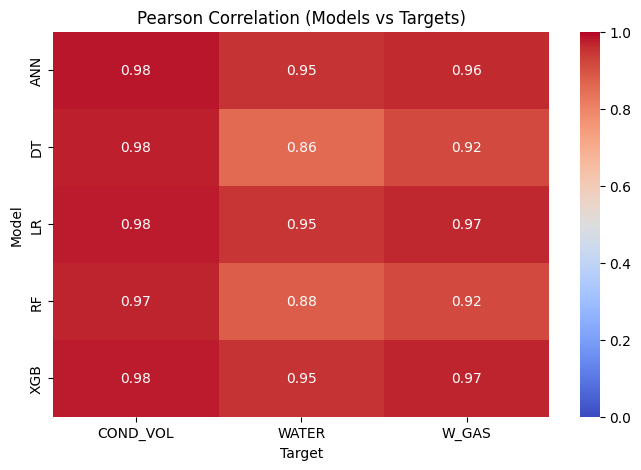

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(pivot_pearson, annot=True, cmap="coolwarm", vmin=0, vmax=1)

plt.title("Pearson Correlation (Models vs Targets)")
plt.show()

In [24]:
os.makedirs("models", exist_ok=True)

# 🔥 sauvegarde config
with open("models/config.json", "w") as f:
    json.dump({
        "features": features,
        "targets": targets
    }, f)

print("✅ Config sauvegardée")

✅ Config sauvegardée


In [25]:
for well in train_wells:

    df_w = df[df["WELL"] == well].sort_values("DATE")

    split_index = int(len(df_w) * 0.8)

    train_part = df_w.iloc[:split_index]
    test_part  = df_w.iloc[split_index:]

    if train_part["DATE"].max() > test_part["DATE"].min():
        print("❌ Problem in well:", well)

In [26]:
print("Train wells:", set(train_df["WELL"]))
print("Blind wells:", set(df_blind["WELL"]))

print("Intersection:", set(train_df["WELL"]).intersection(set(df_blind["WELL"])))

Train wells: {'TFT-316', 'TFT-362', 'TFT-345', 'TFT-319', 'TFT-334Z', 'TFT-324', 'TFT-325', 'TFT-346Z', 'TFT-351', 'TFT-367', 'TFT-356', 'TFT-336', 'TFT-326', 'TFT-347', 'TFT-314', 'TFT-350', 'TFT-338', 'TFT-341Z', 'TFTW-377Z', 'TFTW-705', 'TFT-368', 'TFT-364', 'TFT-385', 'TFT-357', 'TFT-704', 'TFTW-703', 'TFY-30', 'TFT-354', 'TFT-376', 'TFT-355', 'TFT-302', 'TFT-327', 'TFTW-707', 'TFT-383', 'TFT-378', 'TFT-343', 'TFT-360', 'TFT-318', 'TFT-353', 'TFT-313', 'TFT-305', 'TFTW-394Z', 'TFT-332', 'TFT-348', 'TFT-310', 'TFT-374', 'TFT-375', 'TFT-388', 'TFT-380', 'TFT-387', 'TFT-363', 'TFTW-390Z', 'TFT-349', 'TFT-329Z', 'TFT-352', 'TFT-379', 'TFTW-371', 'TFT-308', 'TFT-340', 'TFT-358', 'TFTW-702', 'TFT-344', 'TFT-317', 'TFTW-389', 'TFT-306', 'TFT-384', 'TFT-304', 'TFT-359', 'TFT-331', 'TFT-335Z', 'TFT-315', 'TFT-342', 'TFT-303', 'TFTW-395Z', 'TFT-373', 'TFT-339', 'TFT-369', 'TFT-337', 'TFT-365', 'TFT-366'}
Blind wells: {'TFT-386', 'TFT-370', 'TFT-320', 'TFTW-397', 'TFTW-398', 'TFT-391', 'TFT-3

In [27]:
df_test_shifted = test_df.copy()

for col in targets:
    df_test_shifted[col] = df_test_shifted.groupby("WELL")[col].shift(-1)

df_test_shifted = df_test_shifted.dropna()

X_test_shifted = df_test_shifted[features]
y_test_shifted = df_test_shifted[targets]

y_pred_shifted = xgb_model.predict(X_test_shifted)

from sklearn.metrics import r2_score

for i, target in enumerate(targets):
    print(target)
    print("Shifted R2:", r2_score(y_test_shifted.iloc[:, i], y_pred_shifted[:, i]))

W_GAS
Shifted R2: 0.9494123516090348
WATER
Shifted R2: 0.9389059290868453
COND_VOL
Shifted R2: 0.9481760175271143


In [28]:
# NAIVE MODEL (t = t-1)
df_test_naive = test_df.copy()

df_test_naive["WATER_pred"] = df_test_naive.groupby("WELL")["WATER"].shift(1)

df_test_naive = df_test_naive.dropna()

from sklearn.metrics import r2_score

print("Naive R2:",
      r2_score(df_test_naive["WATER"], df_test_naive["WATER_pred"]))

Naive R2: 0.9715210563739135
